# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


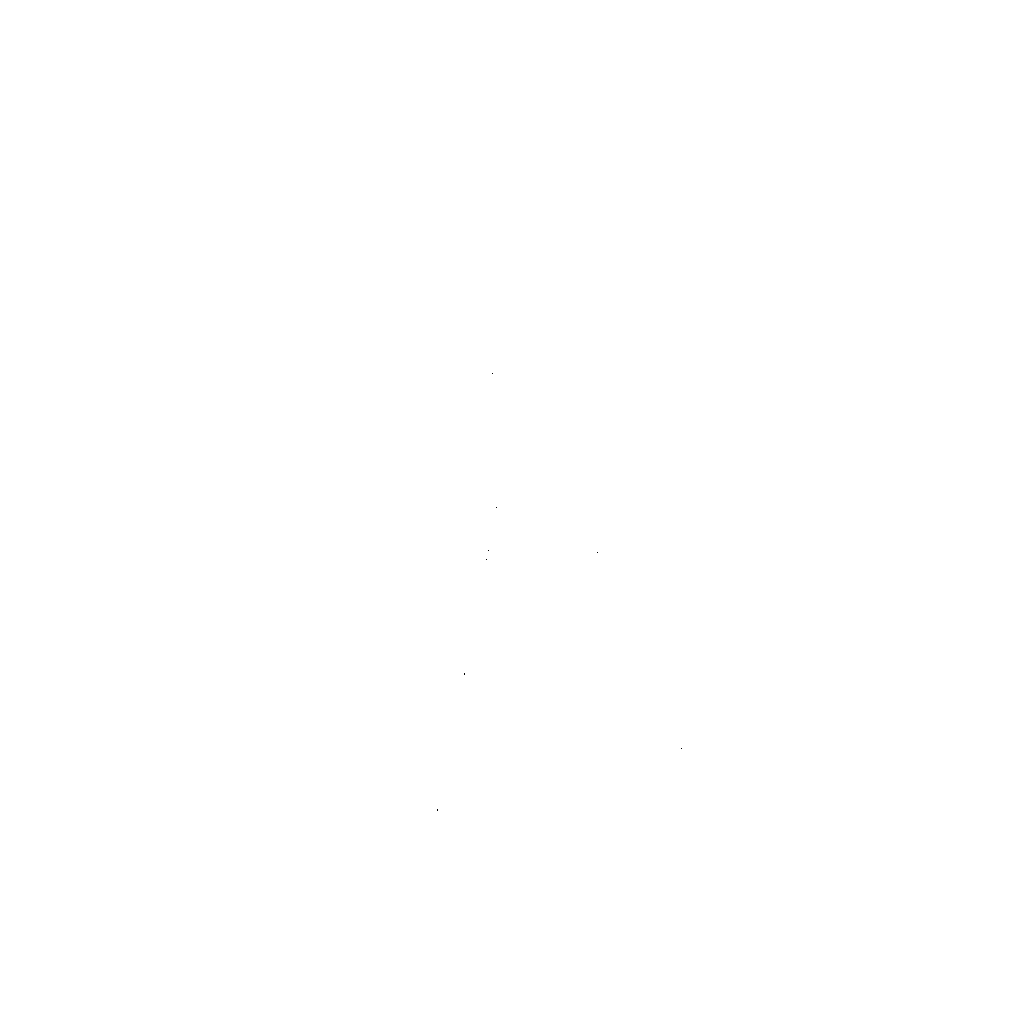

Threshold value: 50


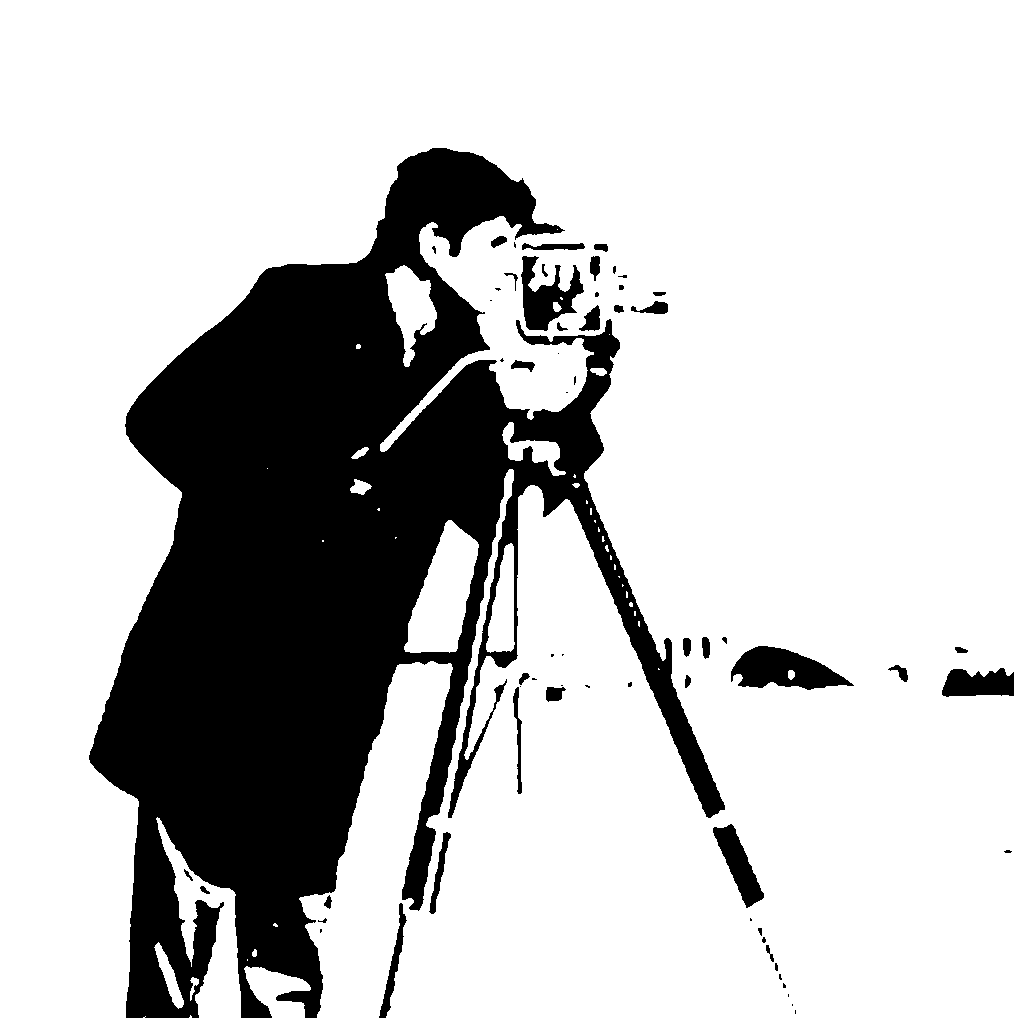

Threshold value: 100


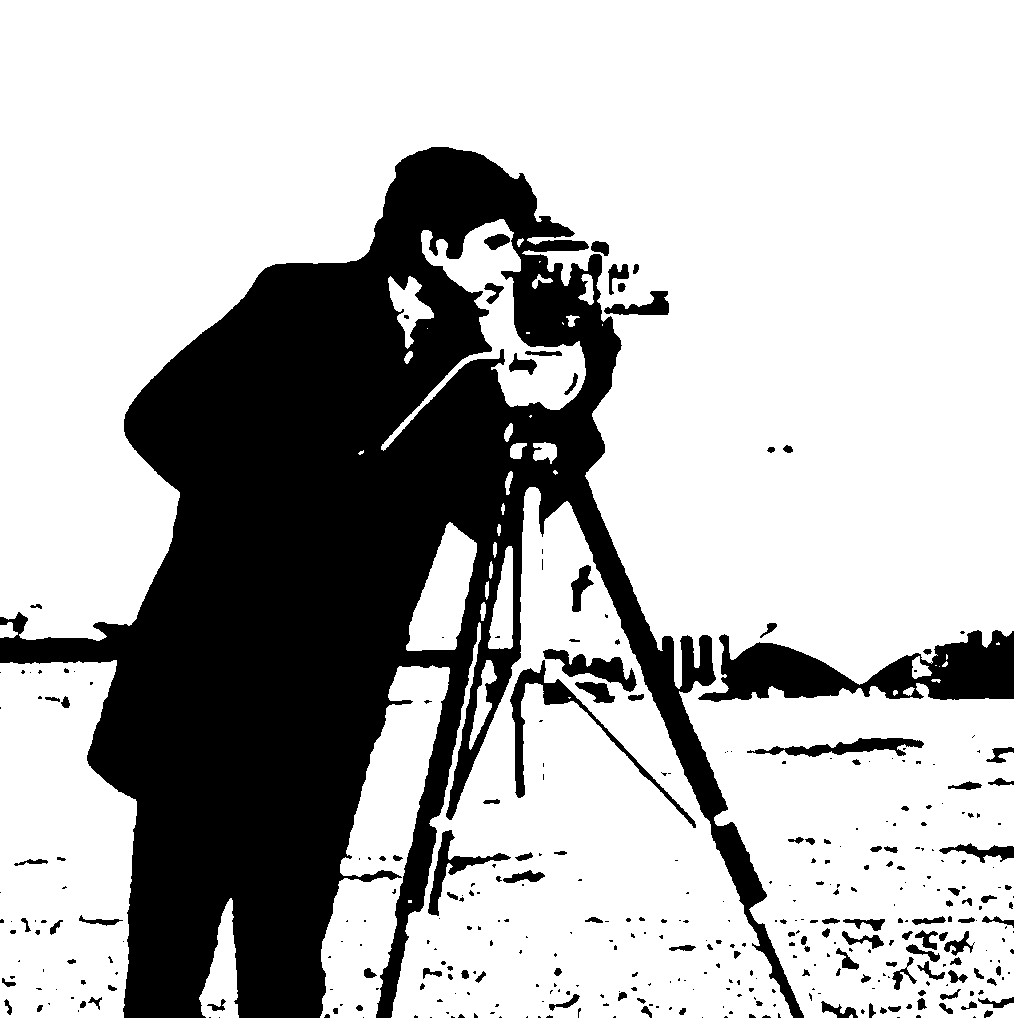

Threshold value: 150


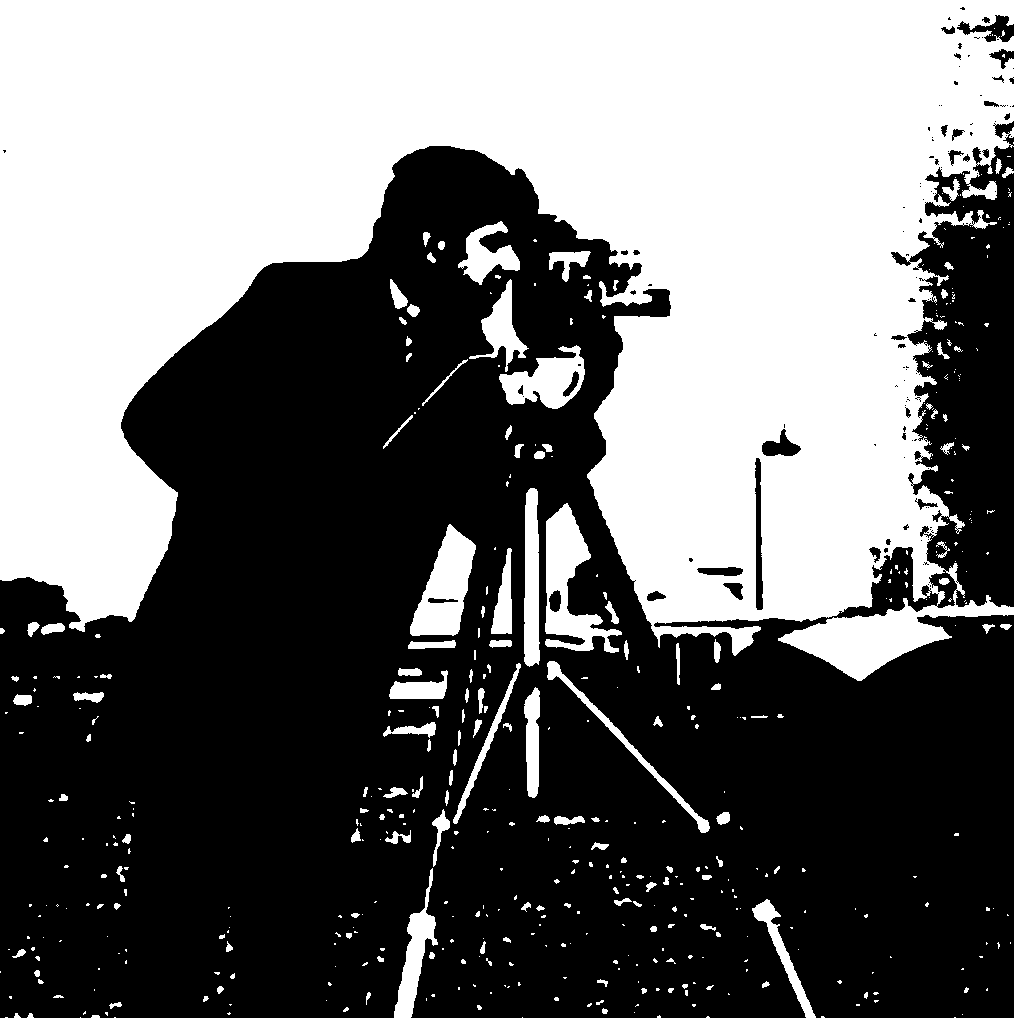

Threshold value: 200


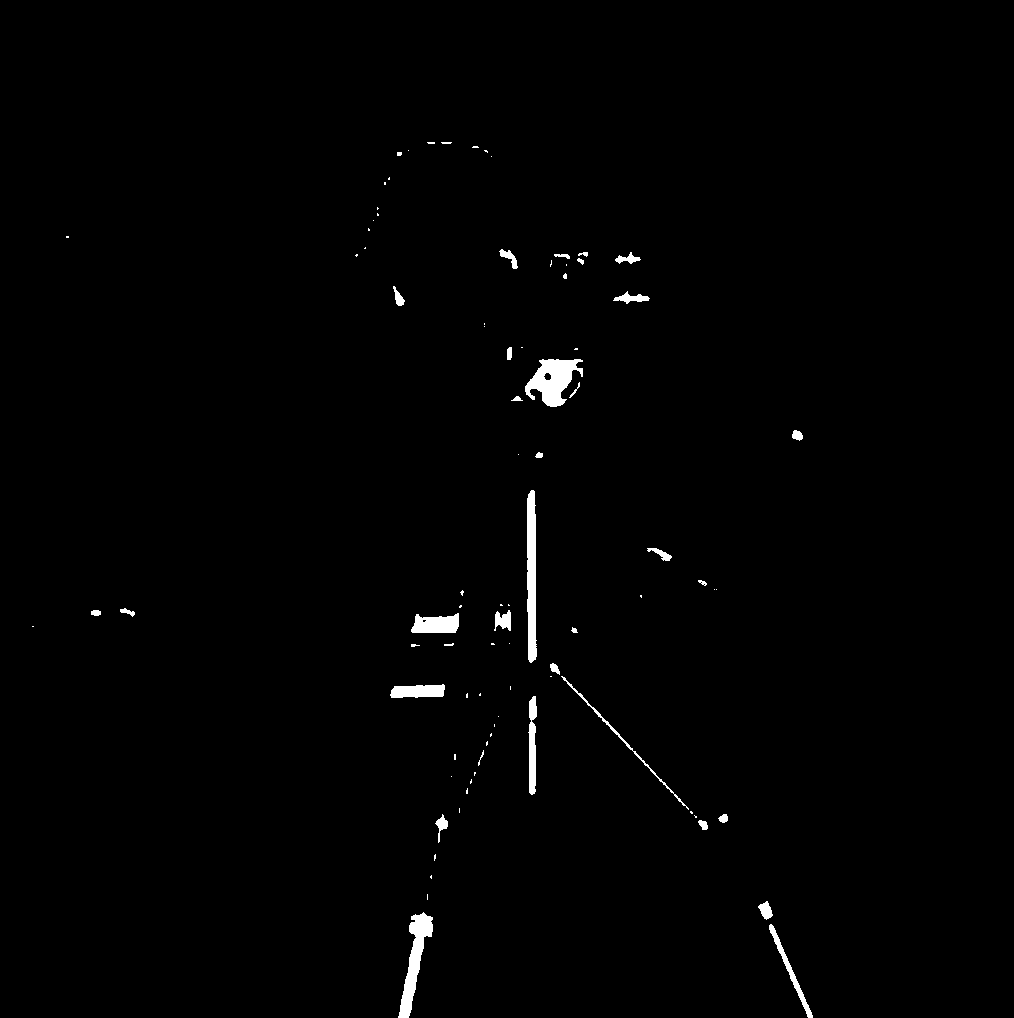

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE) #we added IMREAD_GRAYSCALE, bc imread reads it in black and white (not sure).

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img) #anything 200 and under it is black, above 200 is white (not sure)

Original Image: 


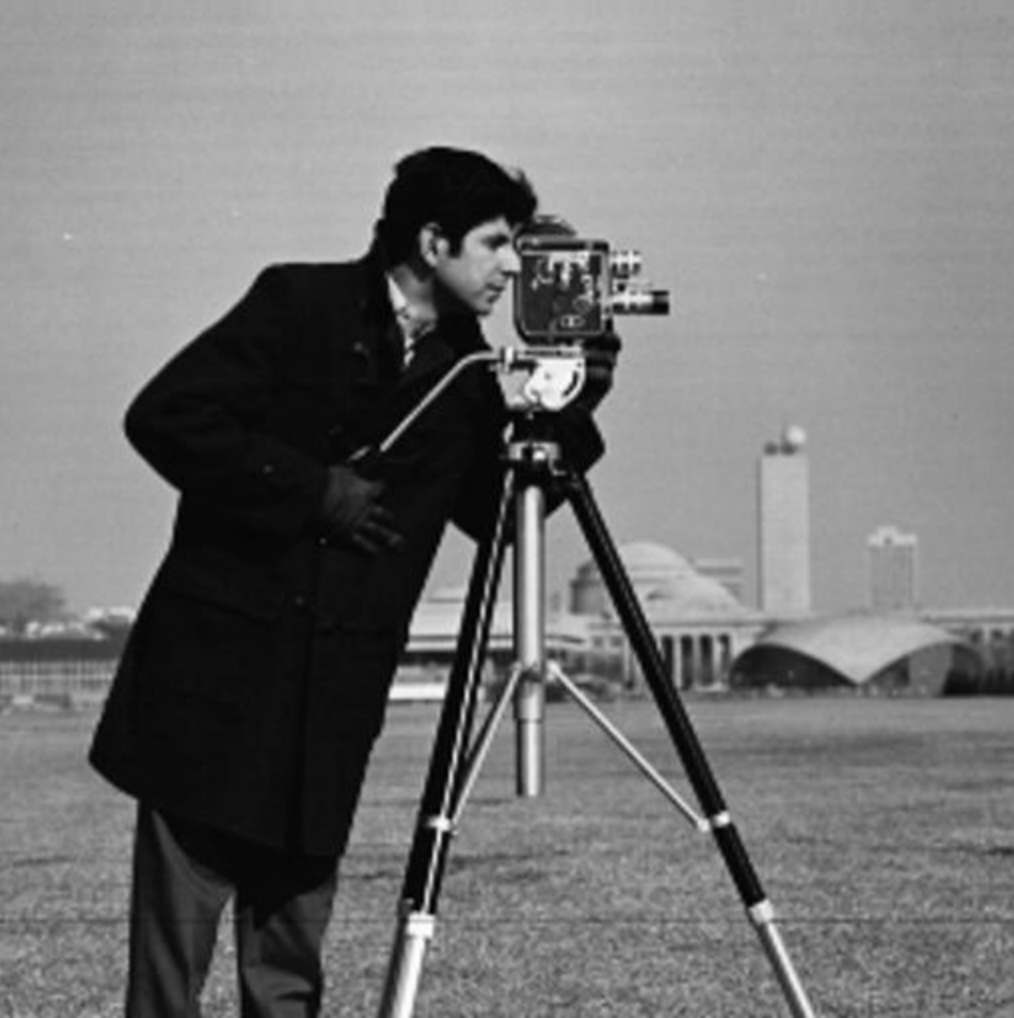

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

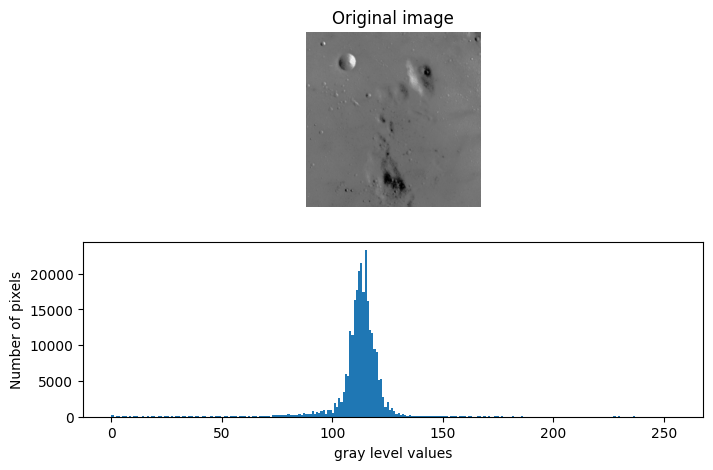

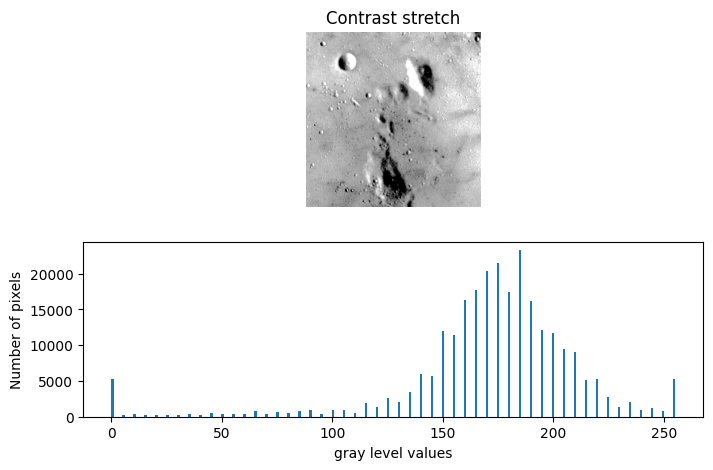

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


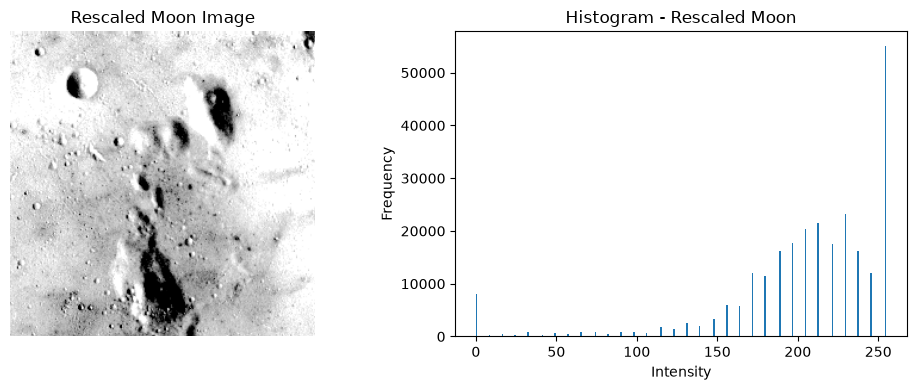

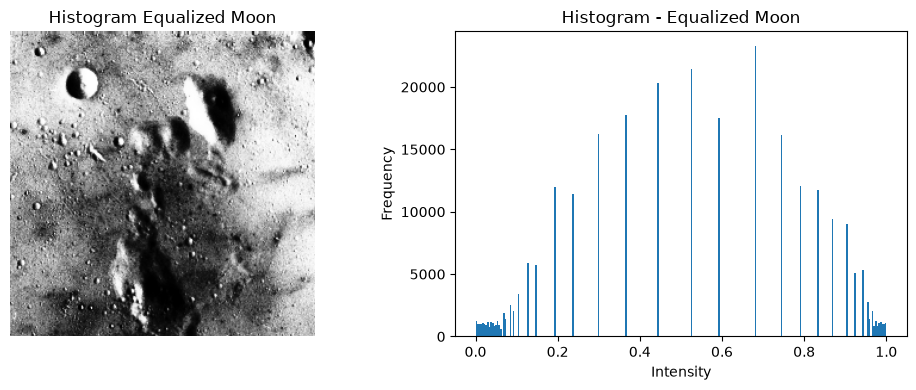

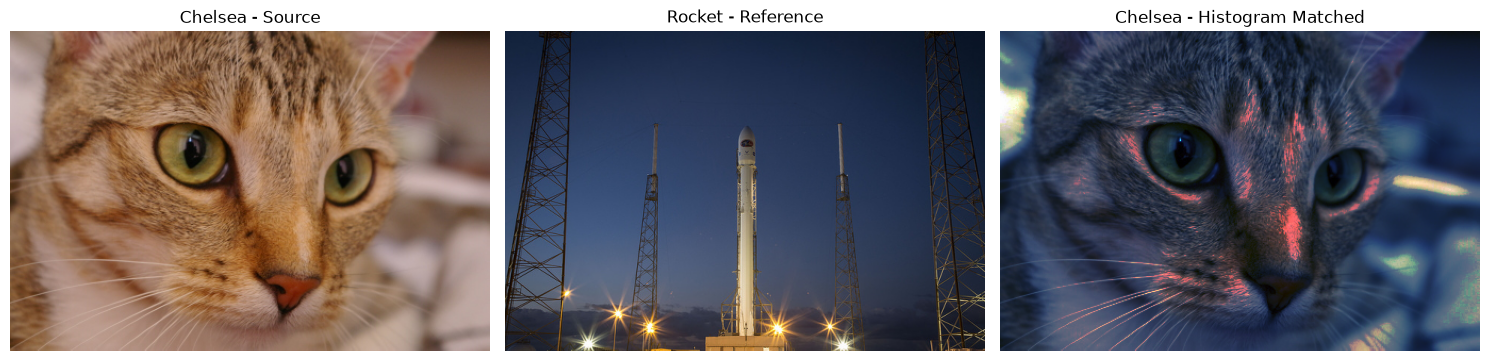

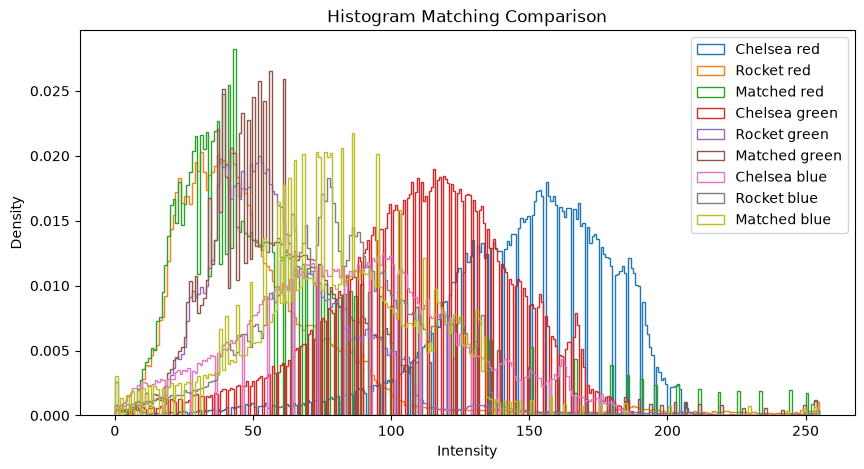

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
from skimage.exposure import match_histograms

# TASK 1: Rescale moon image using the 3rd and 80th percentiles
moon = data.moon()

p3, p80 = np.percentile(moon, (3, 80))
moon_rescaled = exposure.rescale_intensity(moon, in_range=(p3, p80))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(moon_rescaled, cmap='gray')
plt.title('Rescaled Moon Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(moon_rescaled.ravel(), bins=256)
plt.title('Histogram - Rescaled Moon')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# TASK 2: Histogram Equalization of the moon image
moon_equalized = exposure.equalize_hist(moon)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(moon_equalized, cmap='gray')
plt.title('Histogram Equalized Moon')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(moon_equalized.ravel(), bins=256)
plt.title('Histogram - Equalized Moon')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# TASK 3
chelsea = data.chelsea()
rocket = data.rocket()
matched = match_histograms(
    chelsea,
    rocket,
    channel_axis=-1
)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(chelsea)
plt.title('Chelsea - Source')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rocket)
plt.title('Rocket - Reference')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched)
plt.title('Chelsea - Histogram Matched')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(
        chelsea[:, :, i].ravel(),
        bins=256,
        histtype='step',
        density=True,
        label=f'Chelsea {color}'
    )

    plt.hist(
        rocket[:, :, i].ravel(),
        bins=256,
        histtype='step',
        density=True,
        label=f'Rocket {color}'
    )

    plt.hist(
        matched[:, :, i].ravel(),
        bins=256,
        histtype='step',
        density=True,
        label=f'Matched {color}'
    )

plt.title('Histogram Matching Comparison')
plt.xlabel('Intensity')
plt.ylabel('Density')
plt.legend()
plt.show()